In [1]:
import polars as pl
from cryptorandom.cryptorandom import SHA256
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio
import seaborn as sns

sns.set_theme()

import os
os.chdir('../')
from utils import chi2, permutation

seed = 98066
prng = SHA256(seed)

# Q1: Disparities in Charges
In cases in which someone was shot, how does the rate at which Latino vs White/Non-Latino defendants were **charged** with 644/187 (Attempt Murder) compare?

In [2]:
# data loading
df = pl.read_csv("example-1/example_1_data_sanitized.csv")
shooting_cases = df.filter(pl.col("Someone shot? (0=no, 1=yes)") == 1).filter(pl.col("Exclude?").is_null())#.filter(pl.col("Open  = 0; Closed =1") == 1)

In [3]:
# data loading for permutation test
df_pd = shooting_cases.to_pandas()
df_filtered = df_pd[(df_pd["Someone shot? (0=no, 1=yes)"]==1) & (df_pd["Exclude?"].isnull())].reset_index(drop=True) 
# filter for charge, race
df_filtered = df_filtered[["Docket", "Race", "664-187 alleged?"]]
df_white_hispanic = df_filtered[df_filtered["Race"].isin(["W", "H"])].reset_index(drop=True)
df_non_hispanic = df_filtered
df_non_hispanic["race"] = [ "H" if race == "H" else "NH" for race in df_non_hispanic["Race"].to_list()]

## Latino vs White

In [4]:
shooting_cases = df.filter(pl.col("Someone shot? (0=no, 1=yes)") == 1).filter(pl.col("Exclude?").is_null())#.filter(pl.col("Open  = 0; Closed =1") == 1)
shooting_cases_L_W = shooting_cases.group_by(['Race','664-187 alleged?'])\
    .len()\
    .filter(pl.col("Race").str.contains_any(["W","H"]))\
    .pivot(["664-187 alleged?"], index="Race", values="len")\
    .sort("Race")\
    .rename({"0": "664-187 NOT alleged", "1": "664-187 alleged"})

odds_table = shooting_cases_L_W.select("Race","664-187 alleged", "664-187 NOT alleged")
display("Contingency Table For Odds Ratio", odds_table)
odds_ratio_result = odds_ratio(odds_table.drop("Race"))
print(f"The Odds of {odds_table.columns[1]} for {odds_table[0,"Race"]} is {odds_ratio_result.statistic} times that of {odds_table[1,"Race"]} ")

'Contingency Table For Odds Ratio'

Race,664-187 alleged,664-187 NOT alleged
str,u32,u32
"""H""",20,4
"""W""",8,9


The Odds of 664-187 alleged for H is 5.362008590527843 times that of W 


In [5]:
# risk ratio
t = odds_table.to_pandas().set_index("Race")
(t.at["H", "664-187 alleged"]  / (t.at["H", "664-187 alleged"] + t.at["H", "664-187 NOT alleged"] ))/ \
(t.at["W", "664-187 alleged"]  / (t.at["W", "664-187 alleged"] + t.at["W", "664-187 NOT alleged"] ))

np.float64(1.7708333333333335)

p-value: 0.04878048780487805, test stat: 6.047080370609781, dof: nan


'EXPECTED'

Race,664-187 NOT alleged,664-187 alleged
str,f64,f64
"""H""",7.609756,16.390244
"""W""",5.390244,11.609756


'OBSERVED'

Race,664-187 NOT alleged,664-187 alleged
str,u32,u32
"""H""",4,20
"""W""",9,8


'RESIDUALS'

,664-187 NOT alleged,664-187 alleged
Race,,
H,-2.459081,2.459081
W,2.921824,-2.921824


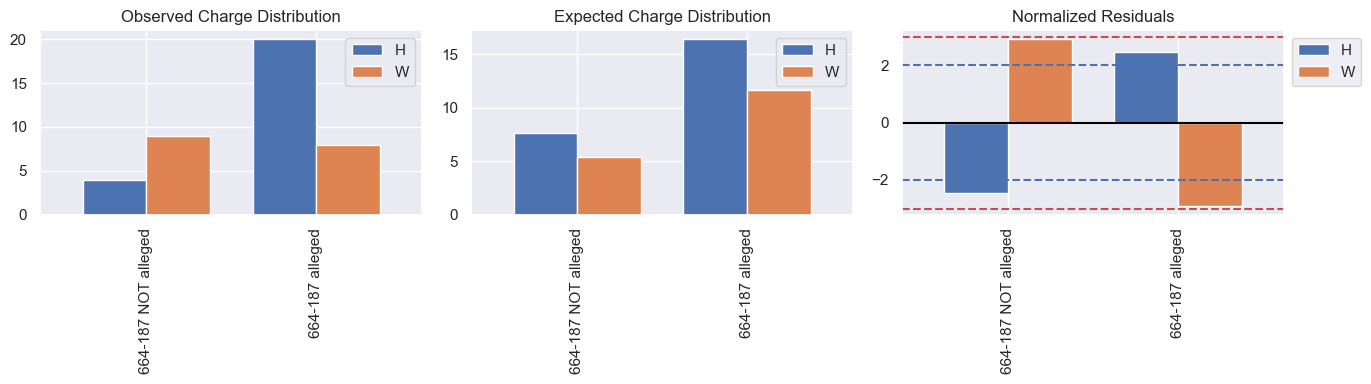

In [6]:
# chi-squared, requirements not met
expected, observed = chi2.test(shooting_cases_L_W)# 
chi2.graph_chi2(expected,observed)

In [7]:
table = shooting_cases_L_W.to_pandas()[["664-187 alleged", "664-187 NOT alleged", "Race"]].set_index("Race").T
table

Race,H,W
664-187 alleged,20,8
664-187 NOT alleged,4,9


In [8]:
# fishers exact 
# null hypothesis: hispanics and non-hispanics are charged with 664-187 at the same rate
# alternative hypothesis: hispanics are sentenced are charged with 664-187 at a greater rate than non-hispanics
res = fisher_exact(table, alternative='greater')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.0171, test stat: 5.625


/opt/anaconda3/envs/rja/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


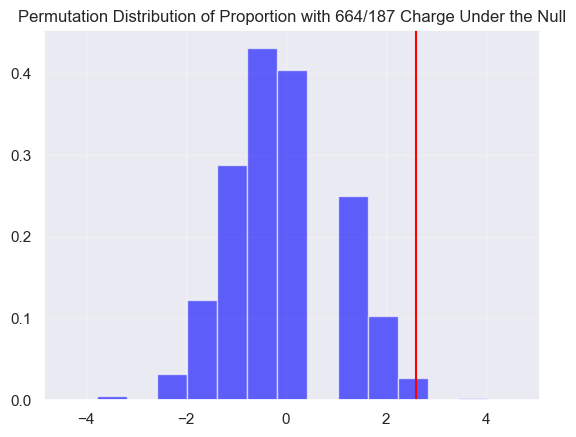

p-value: 0.018, test stat: 2.59755


In [9]:
h_charge, white_charge = permutation.get_lists(df_white_hispanic, "Race", "H", "W", "664-187 alleged?")
_ = permutation.t_test(h_charge, white_charge, "greater", prng=prng, title="Proportion with 664/187 Charge")

In [10]:
# proportion
# def test_stat(df): 
#     return df['664-187 alleged?'].mean()
# n_h = df_white_hispanic["Race"].value_counts()["H"]
# obs_stat = test_stat(df_white_hispanic[df_white_hispanic["Race"]=="H"])
# _, _ = permutation.prop_test(n_h, df_white_hispanic, test_stat, obs_stat, prng=prng, plot_title="Latino v White \n Charged with 664-187", tail="greater")

Latino Vs Non-Latino

In [11]:
shooting_cases_L_NL = shooting_cases.group_by(pl.col('Race').is_in(["H"]),'664-187 alleged?')\
    .len()\
    .with_columns(
        pl.when(pl.col('Race') == True)
        .then(pl.lit("Latino"))
        .otherwise(pl.lit("Non-Latino")).alias("Race")
    )\
    .pivot(["664-187 alleged?"], index="Race", values="len")\
    .sort("Race")\
    .rename({"0": "664-187 NOT alleged", "1": "664-187 alleged"})
    
display(shooting_cases_L_NL)


Race,664-187 alleged,664-187 NOT alleged
str,u32,u32
"""Latino""",20,4
"""Non-Latino""",37,26


In [12]:
odds_table = shooting_cases_L_NL.select("Race","664-187 alleged", "664-187 NOT alleged")
display("Contingency Table For Odds Ratio", odds_table)
odds_ratio_result = odds_ratio(odds_table.drop("Race"))
print(f"The Odds of {odds_table.columns[1]} for {odds_table[0,"Race"]} is {odds_ratio_result.statistic} times that of {odds_table[1,"Race"]} ")

'Contingency Table For Odds Ratio'

Race,664-187 alleged,664-187 NOT alleged
str,u32,u32
"""Latino""",20,4
"""Non-Latino""",37,26


The Odds of 664-187 alleged for Latino is 3.4674670355390496 times that of Non-Latino 


In [13]:
# risk ratio
t = odds_table.to_pandas().set_index("Race")
(t.at["Latino", "664-187 alleged"]  / (t.at["Latino", "664-187 alleged"] + t.at["Latino", "664-187 NOT alleged"] ))/ \
(t.at["Non-Latino", "664-187 alleged"]  / (t.at["Non-Latino", "664-187 alleged"] + t.at["Non-Latino", "664-187 NOT alleged"] ))

np.float64(1.4189189189189189)

p-value: 0.07317073170731707, test stat: 4.656474519632415, dof: nan


'EXPECTED'

Race,664-187 alleged,664-187 NOT alleged
str,f64,f64
"""Latino""",15.724138,8.275862
"""Non-Latino""",41.275862,21.724138


'OBSERVED'

Race,664-187 alleged,664-187 NOT alleged
str,u32,u32
"""Latino""",20,4
"""Non-Latino""",37,26


'RESIDUALS'

,664-187 alleged,664-187 NOT alleged
Race,,
Latino,2.157887,-2.157887
Non-Latino,-1.331877,1.331877


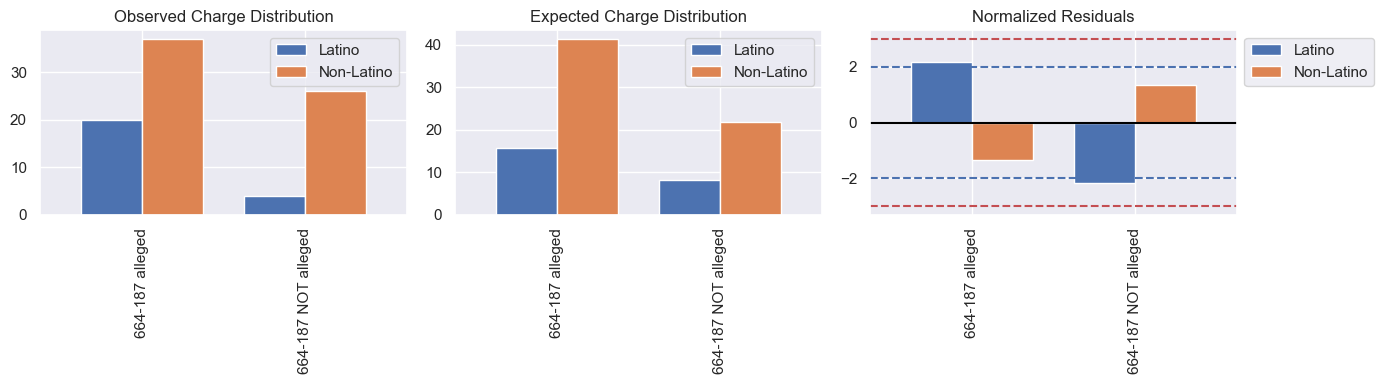

In [14]:
# chi-squared, requirements not met
expected, observed = chi2.test(shooting_cases_L_NL)# 
chi2.graph_chi2(expected,observed)

In [15]:
table = shooting_cases_L_NL.to_pandas()[["664-187 alleged", "664-187 NOT alleged", "Race"]].set_index("Race").T
table

Race,Latino,Non-Latino
664-187 alleged,20,37
664-187 NOT alleged,4,26


In [16]:
# fishers exact 
# null hypothesis: hispanics and non-hispanics are charged with 664-187 at the same rate
# alternative hypothesis: hispanics are sentenced are charged with 664-187 at a greater rate than non-hispanics
res = fisher_exact(table, alternative='greater')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.02539, test stat: 3.5135135135135136


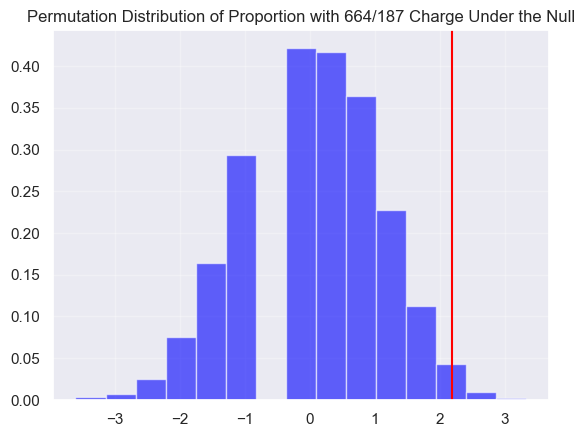

p-value: 0.0254, test stat: 2.19242


In [17]:
h_charge, nh_charge = permutation.get_lists(df_non_hispanic, "race", "H", "NH", "664-187 alleged?")
_ = permutation.t_test(h_charge, nh_charge, "greater", prng=prng, title="Proportion with 664/187 Charge")

In [18]:
# proportion
# def test_stat(df): 
#     return df['664-187 alleged?'].mean()
# n_h = df_non_hispanic["race"].value_counts()["H"]
# obs_stat = test_stat(df_non_hispanic[df_non_hispanic["race"]=="H"])
# _, _ = permutation.prop_test(n_h, df_non_hispanic, test_stat, obs_stat, prng=prng, plot_title="Latino v Non-Latino \n Charged with 664-187", tail="greater")